# Engine Fault Detection — Exploratory Data Analysis
### Machine Learning Course Project | FH Salzburg

---

## Research Question

> *Can engine faults be detected from sensor readings without using any fault data during training, and does a non-linear learned representation outperform classical linear and tree-based approaches for this task?*

This project approaches fault detection as an **unsupervised anomaly detection problem**. In real deployment, labeled fault data is rarely available in sufficient quantity — engines spend most of their operational life running normally. The models in this project are trained exclusively on healthy engine data and evaluated on their ability to flag fault readings they have never seen before.

---

## Dataset — EngineFaultDB

The dataset used is **EngineFaultDB**, introduced by Vergara et al. (2023) and published in IEEE Access. Data was collected from a **C14NE spark ignition engine** under controlled laboratory conditions using an NGA 6000 gas analyzer and a USB 6008 data acquisition card from National Instruments.

The dataset contains **55,999 samples** across **14 sensor features** and four classes:

| Label | Fault Type | Description | Samples |
|---|---|---|---|
| 0 | No fault | Normal engine operation | 16,000 |
| 1 | Fault type 1 | Rich mixture (high fuel, clogged air filter, defective injector) | 10,998 |
| 2 | Fault type 2 | Lean mixture (low fuel pressure, faulty pressure regulator) | 15,000 |
| 3 | Fault type 3 | Low voltage (worn spark plugs, faulty ignition cables, defective coil) | 14,001 |

**Features measured:**
MAP (intake manifold pressure), TPS (throttle position), Force (engine torque), Power, RPM, Fuel consumption L/H, Fuel consumption L/100KM, Speed, CO, HC, CO2, O2, Lambda, AFR.

---

## CRISP-DM Structure

This project follows the full CRISP-DM data mining lifecycle:

1. **Business Understanding** — define the problem and success criteria
2. **Data Understanding** — explore the dataset (this notebook)
3. **Data Preparation** — normalization, train/test split, fault subsampling
4. **Modeling** — PCA baseline, Isolation Forest baseline, Autoencoder
5. **Evaluation** — ROC-AUC, F1, Recall, confusion matrices, model comparison
6. **Deployment** — discussion of real-world applicability and limitations

---

## Citation

> Vergara, M., Ramos, L., Rivera-Campoverde, N. D., & Rivas-Echeverría, F. (2023). EngineFaultDB: A Novel Dataset for Automotive Engine Fault Classification and Baseline Results. *IEEE Access*, 11, 126155–126171. https://doi.org/10.1109/ACCESS.2023.3331316

In [ ]:
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns

In [ ]:
dataset = pd.read_csv(r'E:\AISP\2nd semester\Machine Learning\Anomaly_Detection\Anomaly_Detection\data\EngineFaultDB_Final.csv')
dataset.head()

,Fault,MAP,TPS,Force,Power,RPM,Consumption L/H,Consumption L/100KM,Speed,CO,HC,CO2,O2,Lambda,AFR
0,0,3.549,1.889,7.428,5.227,1192.769,3.057,11.720,24.901,0.460,196.089,14.356,1.080,1.047,15.385
1,0,3.559,1.899,7.646,5.327,1145.191,2.914,11.276,25.030,0.478,196.283,14.492,1.107,1.083,15.926
2,0,3.539,1.899,7.578,5.100,1208.505,2.976,11.926,24.213,0.464,200.367,14.443,1.099,1.072,15.754
3,0,3.519,1.889,7.371,5.255,1164.127,2.908,11.786,24.407,0.471,195.345,13.853,1.076,1.006,14.787
4,0,3.549,1.879,7.405,5.177,1172.032,2.898,12.169,24.875,0.468,194.979,13.752,1.060,0.984,14.470


In [ ]:
# Check the unique values for label column "Fault"
dataset["Fault"].unique()

array([0, 1, 2, 3])

Fault
0    16000
2    15000
3    14001
1    10998
Name: count, dtype: int64


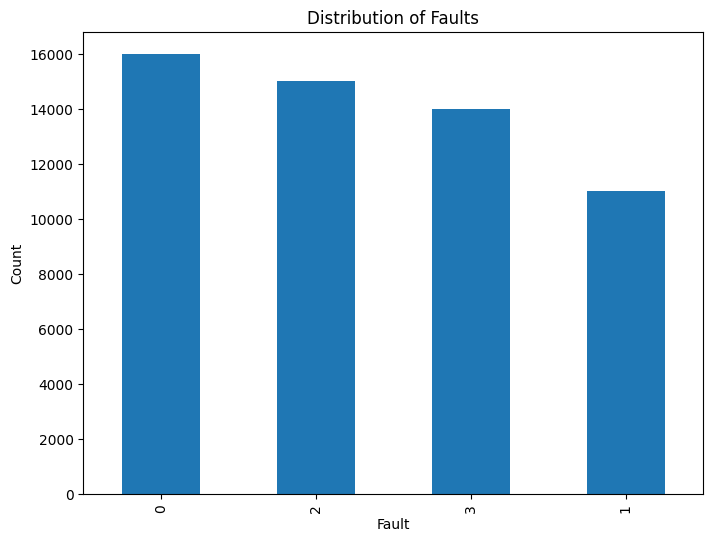

In [ ]:
count = dataset["Fault"].value_counts()
print(count)
# Plot the distribution of the "Fault" column
plt.figure(figsize=(8, 6))
dataset["Fault"].value_counts().plot(kind="bar")
plt.xlabel("Fault")
plt.ylabel("Count")
plt.title("Distribution of Faults")
plt.show()

In [ ]:
dataset.isnull().sum()

Fault                  0
MAP                    0
TPS                    0
Force                  0
Power                  0
RPM                    0
Consumption L/H        0
Consumption L/100KM    0
Speed                  0
CO                     0
HC                     0
CO2                    0
O2                     0
Lambda                 0
AFR                    0
dtype: int64

In [ ]:
dataset.describe()

,Fault,MAP,TPS,Force,Power,RPM,Consumption L/H,Consumption L/100KM,Speed,CO,HC,CO2,O2,Lambda,AFR
count,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000
mean,1.482187,1.832515,1.395269,286.691705,5.657126,2398.053774,4.497634,8.939794,51.688740,1.932430,188.446083,13.035230,0.585910,0.963907,14.169408
std,1.149430,0.837786,0.906950,378.774917,7.684147,932.008680,2.221497,3.154110,20.140345,1.988789,111.047015,1.046567,0.223713,0.065973,0.969802
min,0.000000,0.453000,0.382000,2.580000,0.465000,1066.452000,1.917000,5.187000,22.757000,0.421000,1.787000,8.649000,0.203000,0.695000,10.210000
25%,0.000000,1.217000,0.901000,76.848500,0.994000,1830.200500,2.981000,6.573000,39.412000,0.641000,158.803000,12.842000,0.415000,0.937000,13.780000
50%,2.000000,1.543000,1.013000,92.500000,2.398000,2105.588000,3.824000,8.068000,45.393000,1.129000,178.265000,13.242000,0.533000,0.977000,14.365000
75%,3.000000,1.940000,1.258000,257.989500,4.696000,2761.373500,5.144500,9.924000,59.508000,2.455000,203.678000,13.639000,0.789000,1.008000,14.823000
max,3.000000,4.547000,4.048000,1537.118000,33.946000,5013.402000,14.810000,20.043000,107.539000,10.132000,975.657000,15.129000,1.151000,1.149000,16.893000


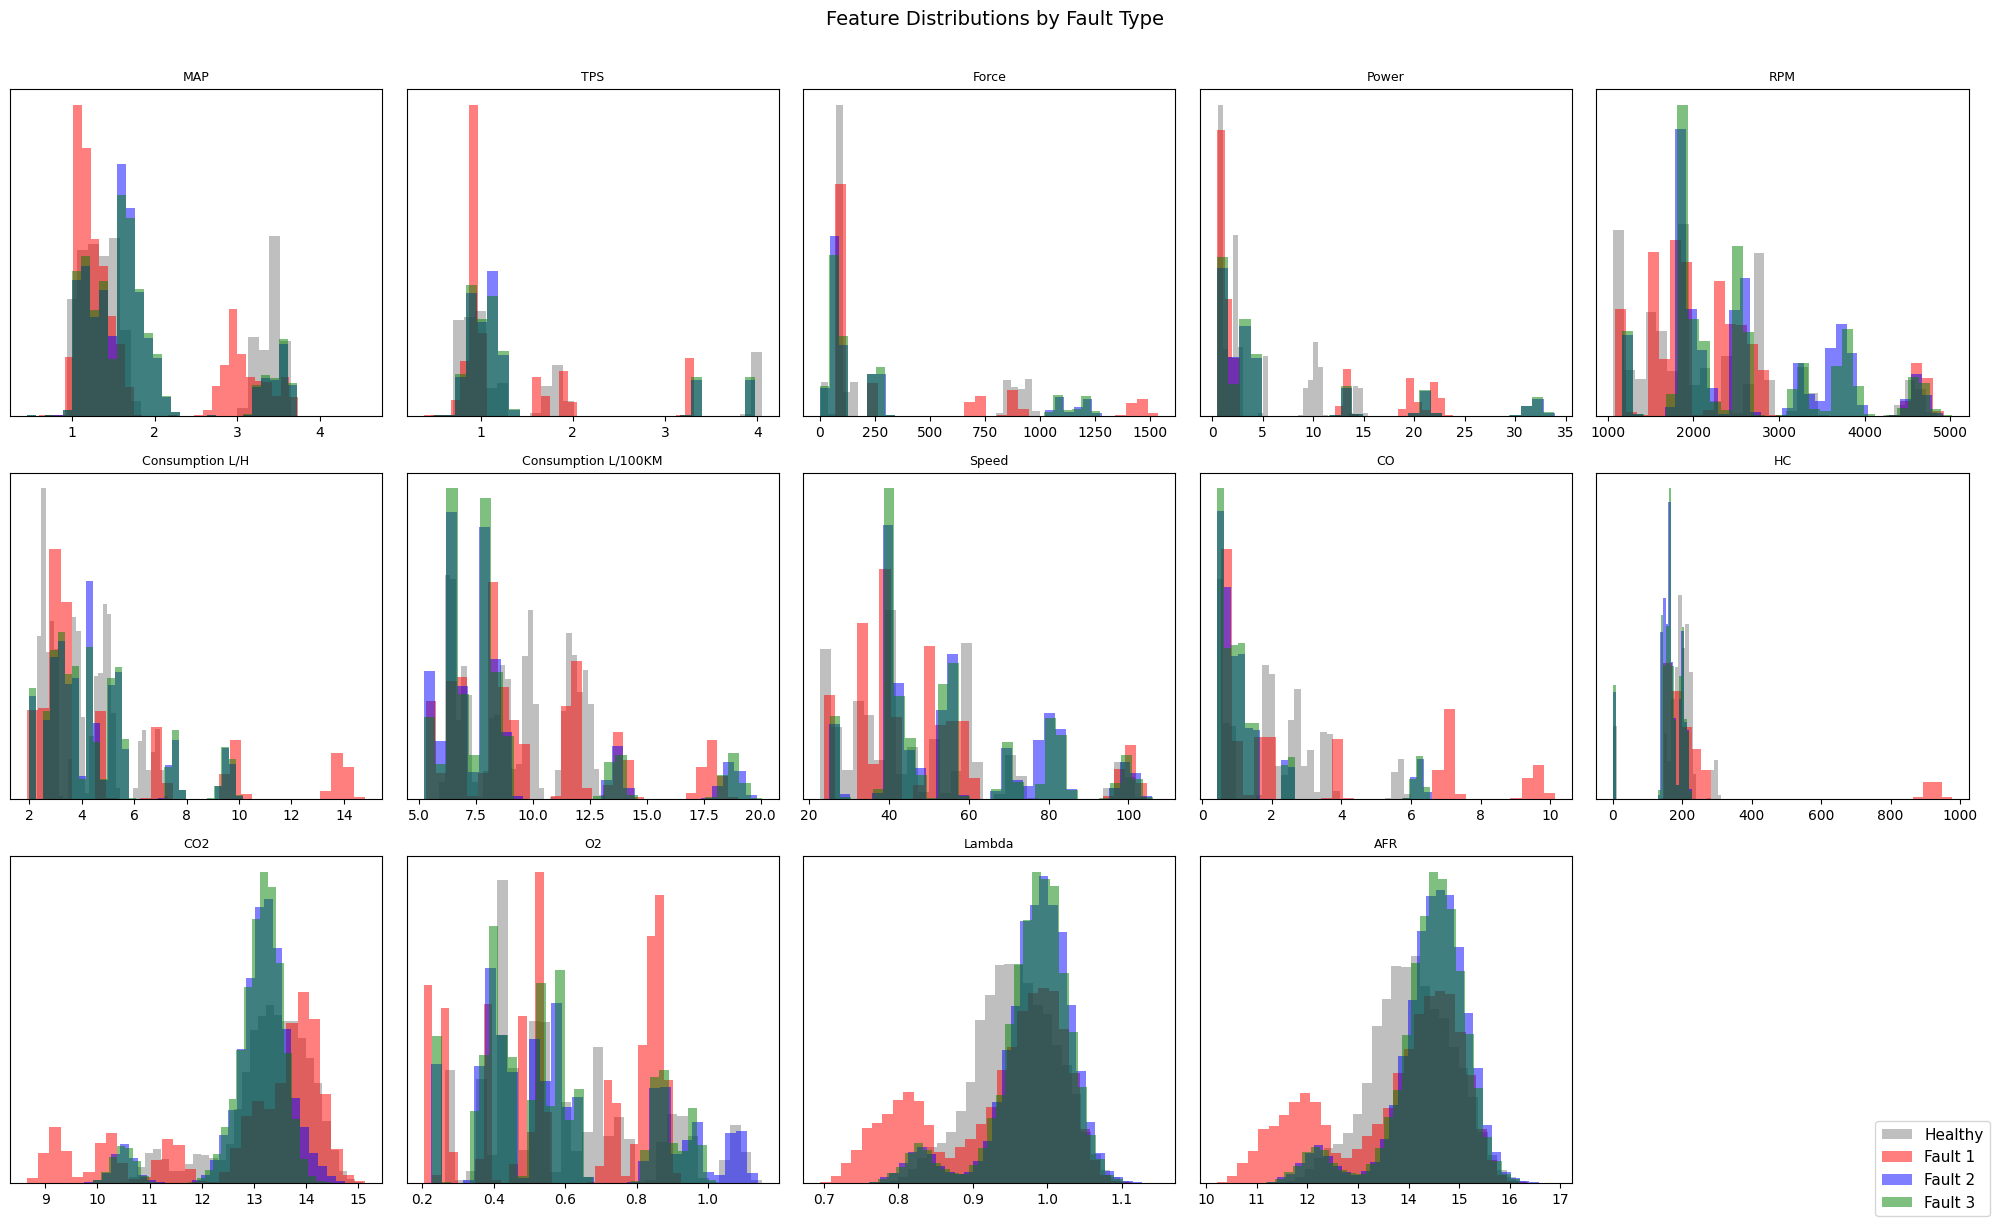

In [ ]:
feature_cols = [col for col in dataset.columns if col != "Fault"]  

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
colors = ["grey", "red", "blue", "green"]
labels = ["Healthy", "Fault 1", "Fault 2", "Fault 3"]

for ax, col in zip(axes.flatten(), feature_cols):
    for fault, color, label in zip([0, 1, 2, 3], colors, labels):
        subset = dataset[dataset["Fault"] == fault][col]
        ax.hist(subset, bins=30, alpha=0.5, color=color,
                label=label, density=True)
    ax.set_title(col, fontsize=9)
    ax.set_yticks([])

# hide the empty 15th subplot
axes.flatten()[-1].set_visible(False)

# one shared legend for all subplots
handles, labels_ = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower right", fontsize=11)

plt.suptitle("Feature Distributions by Fault Type", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../figures/feature_distributions.png", bbox_inches="tight")
plt.show()

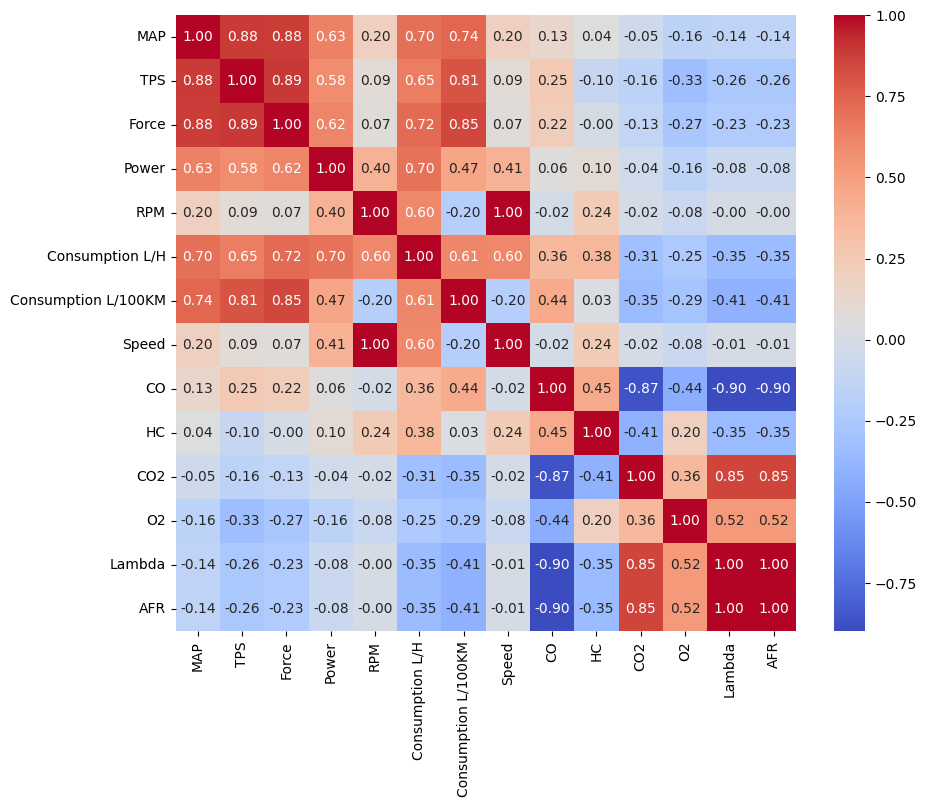

In [ ]:
 # Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(dataset.drop("Fault", axis=1).corr(), 
            annot=
            True, fmt=".2f", cmap="coolwarm")
plt.savefig("../figures/correlation_heatmap.png")
